# Q4

A solid steel shaft carries belt tension at pulley C as shown in Figure 1. Bearing at both ends of the shaft are taken to be identical 02 series deep groove and subjected to light shock loading. The inner ring rotates and operating at a speed of 1800 rpm. The average life of 10 years at 10 hours per day and 300 working day per years. Determine:

i - The radial load

ii - The diameter of the bearing

iii - Median life

iv - Expected rating life if 5% probability of failure can be permitted at 1200 rpm


In [9]:
# Required
# from math import sin, cos, tan, pi, atan, degrees, radians
from matplotlib import pyplot as plt
import numpy as np

In [10]:
print(f'Bore diameter of bearing is unknown')
a_bearingType = 3
Ks = 1.5
V_rotationfactor = 1.0
n_rpm = 1800
rating_life_L10 = 10*10*300
print(f'Rating Life: {rating_life_L10} hours')

Bore diameter of bearing is unknown
Rating Life: 30000 hours


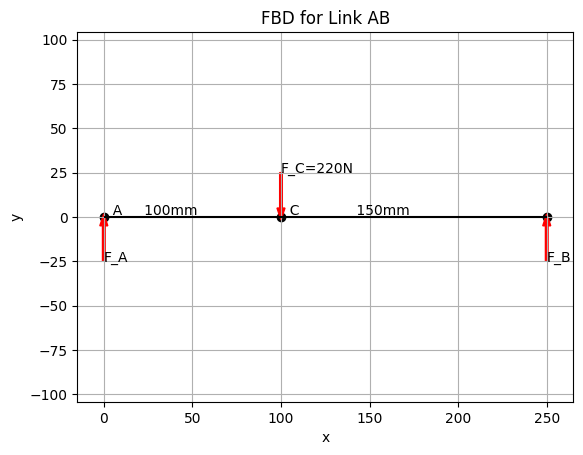

In [11]:
# FBD for Link AB

coorA = [0,0]
coorB = [250,0]
coorC = [100,00]

data = np.array([coorA,coorB,coorC])
x, y = data.T
fig, ax = plt.subplots()
ax.grid()
ax.scatter(x,y, color='k')
ax.arrow(coorA[0],coorA[1]-25, 0,20,width=1.5,color='r')
ax.arrow(coorB[0],coorB[1]-25, 0,20,width=1.5,color='r')
ax.vlines(coorC[0],0,coorC[1], color='k', linestyles='dashed')
ax.arrow(coorC[0],coorC[1]+25, 0,-20,width=1.5,color='r')
ax.hlines(0,0,250, color='k')

ax.set(xlabel='x', ylabel='y',
       title='FBD for Link AB')

ax.text(coorA[0],coorA[1]-25,f'F_A')
ax.text(coorB[0],coorB[1]-25,f'F_B')
ax.text(coorC[0],coorC[1]+25,f'F_C=220N')
ax.text(coorA[0],coorA[1]+1,f'  A     100mm')
ax.text(coorC[0],coorC[1]+1,f'  C             150mm')

plt.axis('equal')
plt.show()

$$+\circlearrowleft \sum M_A=0$$
$$-F_C(0.1)+F_B(0.25)=0$$
$$-(220)(0.1)+F_B(0.25)=0$$

$$+\uparrow \sum F_x=0$$
$$F_A+F_B-220=0$$

In [12]:
Fb=220*0.1/0.25
print(f'Reaction at B, Fb = {Fb:.2f} N')
Fa=220-Fb
print(f'Reaction at A, Fa = {Fa:.2f} N')

Reaction at B, Fb = 88.00 N
Reaction at A, Fa = 132.00 N


In [13]:
P_A = Ks*V_rotationfactor*Fa
P_B = Ks*V_rotationfactor*Fb
print(f'Equivalent Radial Load at A, P_A = {P_A:.2f} N')
print(f'Equivalent Radial Load at B, P_B = {P_B:.2f} N')

Equivalent Radial Load at A, P_A = 198.00 N
Equivalent Radial Load at B, P_B = 132.00 N


In [14]:
P=P_A
print(f'Equivalent Radial load at bearing A is larger than B')

Equivalent Radial load at bearing A is larger than B


**Rating Life, $L_{10}$**

$$
L_{10} = \frac{10^6}{60*n_{rpm}} \left( \frac{C}{P} \right)^a$$

In [15]:
C = (rating_life_L10*60*n_rpm/1e6)**(1/3)*P
print(f'Required Dynamic Load Rating, C = {C:.2f} N')

Required Dynamic Load Rating, C = 2929.86 N


Table 3.1

| D | C (kN) | Cs(kN) |
|:--------:|:--------:|:--------:|
|  10   |  5.07   |  2.24   |

In [16]:
Kr=0.62
C_new = 5070
n_rpm_new=1200
L5 = Kr*1e6/(60*n_rpm_new)*(C_new/P)**3
print(f'Bearing Life with C=5.07kN at 1200rpm: L5 = {L5:.0f} hours')

Bearing Life with C=5.07kN at 1200rpm: L5 = 144573 hours
